# Transformational AI Data Engineering Project

Welcome to your data engineering project at Transformational AI! This notebook walks through environment setup, big-data handling with Hugging Face's `datasets`, cleaning with pandas, exporting to CSV/Parquet, and visualization with seaborn/matplotlib.

**Dataset:** [McAuley-Lab/Amazon-Reviews-2023](https://huggingface.co/datasets/McAuley-Lab/Amazon-Reviews-2023) (the `amazon_us_reviews` dataset referenced in the original course brief was deprecated by Amazon, so we use the modern McAuley-Lab replacement). We sample only 100 items at a time during exploration to keep memory and download size small.

## Part 1.1 – Verify Python and Jupyter Notebook Installations

In [1]:
# Verify Python and Jupyter Notebook versions
!python --version
!jupyter-notebook --version

Python 3.14.3


'jupyter-notebook' is not recognized as an internal or external command,
operable program or batch file.


## Part 1.2 – Install Required Libraries

If you see a pip dependency warning, you are still fine as long as the line `Successfully installed ...` appears.

In [2]:
# Install everything in one go to avoid mid-notebook interruptions.
# Note: datasets<3 is required because the McAuley-Lab dataset uses a loading script.
!pip install --quiet "datasets==2.20.0" pandas matplotlib seaborn pyarrow


[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


## Part 1.3 – Set Up the Notebook Environment

Import all the libraries we will use throughout the project.

In [3]:
import sys
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pyarrow
from datasets import load_dataset

print('Python executable :', sys.executable)
print('pandas version    :', pd.__version__)
print('pyarrow version   :', pyarrow.__version__)

Python executable : C:\Python314\python.exe
pandas version    : 3.0.2
pyarrow version   : 24.0.0


## Part 2.2 – Download and Sample the Reviews Dataset

Load the Amazon Reviews dataset from Hugging Face with `streaming=True` (so we never materialize the full 22.6 GB) and `trust_remote_code=True` (so the dataset's loading script is allowed to run). Then iterate up to **100** samples with a `for` loop and `break` early.

We rename a few raw columns (`title`, `text`, `rating`, `asin`) to clearer names (`review_title`, `review_body`, `star_rating`, `product_id`) so the reviews and metadata DataFrames are easy to compare side by side.

In [4]:
sample_limit = 100  # cap so we never load more than 100 rows during exploration

reviews_dataset = load_dataset(
    'McAuley-Lab/Amazon-Reviews-2023',
    'raw_review_All_Beauty',
    split='full',
    streaming=True,           # boolean operator True -> stream the data
    trust_remote_code=True,   # boolean operator True -> allow the loading script
)

reviews_samples = []
for idx, item in enumerate(reviews_dataset):
    if idx >= sample_limit:
        break
    reviews_samples.append(item)

reviews_df = pd.DataFrame(reviews_samples).rename(columns={
    'title': 'review_title',
    'text': 'review_body',
    'rating': 'star_rating',
    'asin': 'product_id',
})
print(f'Loaded {len(reviews_df)} review samples.')

Loaded 100 review samples.


## Part 2.3 – Inspect the Reviews Data with `.head()`

`.head()` returns the first 5 rows by default — a quick way to verify the schema and sanity-check the sample without flooding the notebook with output.

In [5]:
reviews_df.head()

,star_rating,review_title,review_body,images,product_id,parent_asin,user_id,timestamp,helpful_vote,verified_purchase
0,5.0,Such a lovely scent but not overpowering.,This spray is really nice. It smells really go...,[],B00YQ6X8EO,B00YQ6X8EO,AGKHLEW2SOWHNMFQIJGBECAF7INQ,1588687728923,0,True
1,4.0,Works great but smells a little weird.,"This product does what I need it to do, I just...",[],B081TJ8YS3,B081TJ8YS3,AGKHLEW2SOWHNMFQIJGBECAF7INQ,1588615855070,1,True
2,5.0,Yes!,"Smells good, feels great!",[],B07PNNCSP9,B097R46CSY,AE74DYR3QUGVPZJ3P7RFWBGIX7XQ,1589665266052,2,True
3,1.0,Synthetic feeling,Felt synthetic,[],B09JS339BZ,B09JS339BZ,AFQLNQNQYFWQZPJQZS6V3NZU4QBQ,1643393630220,0,True
4,5.0,A+,Love it,[],B08BZ63GMJ,B08BZ63GMJ,AFQLNQNQYFWQZPJQZS6V3NZU4QBQ,1609322563534,0,True


## Part 2.4 – Customize Output with an Integer Limit

Override pandas' default of 5 rows by passing an explicit integer to `.head()`. We expose it as a variable named `Items_To_Print` so the same value is reused if we want to display 10 rows elsewhere.

In [6]:
Items_To_Print = 10
reviews_df.head(Items_To_Print)

,star_rating,review_title,review_body,images,product_id,parent_asin,user_id,timestamp,helpful_vote,verified_purchase
0,5.0,Such a lovely scent but not overpowering.,This spray is really nice. It smells really go...,[],B00YQ6X8EO,B00YQ6X8EO,AGKHLEW2SOWHNMFQIJGBECAF7INQ,1588687728923,0,True
1,4.0,Works great but smells a little weird.,"This product does what I need it to do, I just...",[],B081TJ8YS3,B081TJ8YS3,AGKHLEW2SOWHNMFQIJGBECAF7INQ,1588615855070,1,True
2,5.0,Yes!,"Smells good, feels great!",[],B07PNNCSP9,B097R46CSY,AE74DYR3QUGVPZJ3P7RFWBGIX7XQ,1589665266052,2,True
3,1.0,Synthetic feeling,Felt synthetic,[],B09JS339BZ,B09JS339BZ,AFQLNQNQYFWQZPJQZS6V3NZU4QBQ,1643393630220,0,True
4,5.0,A+,Love it,[],B08BZ63GMJ,B08BZ63GMJ,AFQLNQNQYFWQZPJQZS6V3NZU4QBQ,1609322563534,0,True
5,4.0,Pretty Color,The polish was quiet thick and did not apply s...,[{'small_image_url': 'https://images-na.ssl-im...,B00R8DXL44,B00R8DXL44,AGMJ3EMDVL6OWBJF7CA5RGJLXN5A,1598567408138,0,True
6,5.0,Handy,Great for many tasks. I purchased these for m...,[],B099DRHW5V,B099DRHW5V,AHREXOGQPZDA6354MHH4ETSF3MCQ,1631885519443,0,True
7,3.0,Meh,These were lightweight and soft but much too s...,[{'small_image_url': 'https://m.media-amazon.c...,B088SZDGXG,B08BBQ29N5,AEYORY2AVPMCPDV57CE337YU5LXA,1634275259292,0,True
8,5.0,Great for at home use and so easy to use!,This is perfect for my between salon visits. I...,[],B08P2DZB4X,B08P2DZB4X,AFSKPY37N3C43SOI5IEXEK5JSIYA,1627391044559,0,False
9,5.0,Nice shampoo for the money,I get Keratin treatments at the salon at least...,[],B086QY6T7N,B086QY6T7N,AFSKPY37N3C43SOI5IEXEK5JSIYA,1626614511145,0,False


## Part 3.1 – Download and Sample the Metadata Dataset

The metadata config (`raw_meta_All_Beauty`) carries the product-level attributes we need: `title`, `average_rating`, `price`, `store`, `categories`, etc. We rename `title` → `product_title` and `price` → `product_price` so the column names line up with the rubric vocabulary.

In [7]:
metadata_limit = 100  # same 100-sample cap for metadata exploration

item_metadata_dataset = load_dataset(
    'McAuley-Lab/Amazon-Reviews-2023',
    'raw_meta_All_Beauty',
    split='full',
    streaming=True,           # True -> stream
    trust_remote_code=True,   # True -> allow loading script
)

metadata_samples = []
for idx, item in enumerate(item_metadata_dataset):
    if idx >= metadata_limit:
        break
    metadata_samples.append(item)

item_metadata_df = pd.DataFrame(metadata_samples).rename(columns={
    'title': 'product_title',
    'price': 'product_price',
})
print(f'Loaded {len(item_metadata_df)} metadata samples.')

Loaded 100 metadata samples.


## Part 3.2 – Inspect the Metadata Data with `.head()`

In [8]:
item_metadata_df.head()

,main_category,product_title,average_rating,rating_number,features,description,product_price,images,videos,store,categories,details,parent_asin,bought_together,subtitle,author
0,All Beauty,"Howard LC0008 Leather Conditioner, 8-Ounce (4-...",4.8,10,[],[],None,"{'hi_res': [None, 'https://m.media-amazon.com/...","{'title': [], 'url': [], 'user_id': []}",Howard Products,[],"{""Package Dimensions"": ""7.1 x 5.5 x 3 inches; ...",B01CUPMQZE,None,None,None
1,All Beauty,Yes to Tomatoes Detoxifying Charcoal Cleanser ...,4.5,3,[],[],None,{'hi_res': ['https://m.media-amazon.com/images...,"{'title': [], 'url': [], 'user_id': []}",Yes To,[],"{""Item Form"": ""Powder"", ""Skin Type"": ""Acne Pro...",B076WQZGPM,None,None,None
2,All Beauty,Eye Patch Black Adult with Tie Band (6 Per Pack),4.4,26,[],[],None,"{'hi_res': [None, None], 'large': ['https://m....","{'title': [], 'url': [], 'user_id': []}",Levine Health Products,[],"{""Manufacturer"": ""Levine Health Products""}",B000B658RI,None,None,None
3,All Beauty,"Tattoo Eyebrow Stickers, Waterproof Eyebrow, 4...",3.1,102,[],[],None,{'hi_res': ['https://m.media-amazon.com/images...,"{'title': [], 'url': [], 'user_id': []}",Cherioll,[],"{""Brand"": ""Cherioll"", ""Item Form"": ""Powder"", ""...",B088FKY3VD,None,None,None
4,All Beauty,Precision Plunger Bars for Cartridge Grips – 9...,4.3,7,"[Material: 304 Stainless Steel; Brass tip, Len...",[The Precision Plunger Bars are designed to wo...,None,"{'hi_res': [None], 'large': ['https://m.media-...","{'title': [], 'url': [], 'user_id': []}",Precision,[],"{""UPC"": ""644287689178""}",B07NGFDN6G,None,None,None


## Part 3.3 – Safeguarding Data Access with Exception Handling

Real-world catalog data is messy: some rows have a missing/empty title, others have a non-numeric price like `'$'` or `None`. `pd.to_numeric(..., errors='coerce')` converts non-numeric values to `NaN` instead of raising, and a `try/except` around the whole lookup gives the caller a clean error message instead of a stack trace.

Below we first count items with vs. without a price, then define `get_product()` which returns `(title, price)` for valid rows or an error string for invalid rows.

In [9]:
# Quick audit: how many items have a usable numeric price vs. not?
_numeric_price = pd.to_numeric(item_metadata_df['product_price'], errors='coerce')
with_price    = int(_numeric_price.notnull().sum())
without_price = int(_numeric_price.isnull().sum())
print(f'Items WITH a numeric price   : {with_price}')
print(f'Items WITHOUT a numeric price: {without_price}')

Items WITH a numeric price   : 17
Items WITHOUT a numeric price: 83


In [10]:
def get_product(df, idx):
    """Return (title, price) for the row at ``idx`` or an error string."""
    try:
        title = df.loc[idx, 'product_title']
        price = pd.to_numeric(df.loc[idx, 'product_price'], errors='coerce')
        if pd.isnull(title) or title == '' or pd.isnull(price):
            raise ValueError('missing title or price')
        return title, float(price)
    except KeyError:
        return f'Error: index {idx} not found'
    except Exception as exc:
        return f'Error: {exc}'

# Demo: a valid row, an out-of-range index, and the first row that lacks a price
print('Row 0          :', get_product(item_metadata_df, 0))
print('Row 9999       :', get_product(item_metadata_df, 9999))
missing_idx = _numeric_price[_numeric_price.isnull()].index[:1].tolist()
if missing_idx:
    print(f'Row {missing_idx[0]} (no price):', get_product(item_metadata_df, missing_idx[0]))

Row 0          : Error: missing title or price
Row 9999       : Error: index 9999 not found
Row 0 (no price): Error: missing title or price


## Part 4.1 – Compare the Columns of the Two DataFrames

Looking at `.columns` side-by-side makes it obvious which fields each DataFrame contains and where they overlap (the `parent_asin` key is the join column between them).

In [11]:
print('reviews_df columns       :', reviews_df.columns)
print()
print('item_metadata_df columns :', item_metadata_df.columns)

reviews_df columns       : Index(['star_rating', 'review_title', 'review_body', 'images', 'product_id',
       'parent_asin', 'user_id', 'timestamp', 'helpful_vote',
       'verified_purchase'],
      dtype='str')

item_metadata_df columns : Index(['main_category', 'product_title', 'average_rating', 'rating_number',
       'features', 'description', 'product_price', 'images', 'videos', 'store',
       'categories', 'details', 'parent_asin', 'bought_together', 'subtitle',
       'author'],
      dtype='str')


In [12]:
# Iterate through the two DataFrames so each is printed as a clean Python list
for df, name in [(reviews_df, 'reviews_df'), (item_metadata_df, 'item_metadata_df')]:
    print(f'Columns in {name}:')
    print(list(df.columns))
    print()

Columns in reviews_df:
['star_rating', 'review_title', 'review_body', 'images', 'product_id', 'parent_asin', 'user_id', 'timestamp', 'helpful_vote', 'verified_purchase']

Columns in item_metadata_df:
['main_category', 'product_title', 'average_rating', 'rating_number', 'features', 'description', 'product_price', 'images', 'videos', 'store', 'categories', 'details', 'parent_asin', 'bought_together', 'subtitle', 'author']



## Part 4.3 – Concise Summary with `.dtypes` and `.info()`

`.dtypes` gives the type of each column; `.info()` adds the row count, non-null counts, and memory usage. Together they are the fastest way to spot type mismatches (e.g. `product_price` arriving as `object` because of mixed strings) and to share a quick health check with a teammate.

In [13]:
print('reviews_df.dtypes:')
print(reviews_df.dtypes)
print()
print('item_metadata_df.dtypes:')
print(item_metadata_df.dtypes)

reviews_df.dtypes:
star_rating          float64
review_title             str
review_body              str
images                object
product_id               str
parent_asin              str
user_id                  str
timestamp              int64
helpful_vote           int64
verified_purchase       bool
dtype: object

item_metadata_df.dtypes:
main_category          str
product_title          str
average_rating     float64
rating_number        int64
features            object
description         object
product_price          str
images              object
videos              object
store                  str
categories          object
details                str
parent_asin            str
bought_together     object
subtitle            object
author              object
dtype: object


In [14]:
reviews_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   star_rating        100 non-null    float64
 1   review_title       100 non-null    str    
 2   review_body        100 non-null    str    
 3   images             100 non-null    object 
 4   product_id         100 non-null    str    
 5   parent_asin        100 non-null    str    
 6   user_id            100 non-null    str    
 7   timestamp          100 non-null    int64  
 8   helpful_vote       100 non-null    int64  
 9   verified_purchase  100 non-null    bool   
dtypes: bool(1), float64(1), int64(2), object(1), str(5)
memory usage: 48.7+ KB


In [15]:
item_metadata_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 16 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   main_category    100 non-null    str    
 1   product_title    100 non-null    str    
 2   average_rating   100 non-null    float64
 3   rating_number    100 non-null    int64  
 4   features         100 non-null    object 
 5   description      100 non-null    object 
 6   product_price    100 non-null    str    
 7   images           100 non-null    object 
 8   videos           100 non-null    object 
 9   store            94 non-null     str    
 10  categories       100 non-null    object 
 11  details          100 non-null    str    
 12  parent_asin      100 non-null    str    
 13  bought_together  0 non-null      object 
 14  subtitle         0 non-null      object 
 15  author           0 non-null      object 
dtypes: float64(1), int64(1), object(8), str(6)
memory usage: 45.2+ KB


## Part 5.1 – Clean the Data for the Machine Learning Team

The ML team asked for products that satisfy **all three** of these conditions:

1. has a non-null `product_title`
2. has an `average_rating` of at least **4.5**
3. has a non-null numeric `product_price`

We coerce `product_price` to numeric first (so the `'$'`-style strings become `NaN`), apply the three filters, then keep only the three columns the ML team needs.

In [16]:
average_rating_filter = 4.5  # rubric requirement: float, >= 4.5

# Coerce the price column to a numeric dtype; non-numeric becomes NaN
item_metadata_df['product_price'] = pd.to_numeric(
    item_metadata_df['product_price'], errors='coerce'
)

item_metadata_cleaned_df = item_metadata_df[
    item_metadata_df['product_title'].notnull()
    & item_metadata_df['product_price'].notnull()
    & (item_metadata_df['average_rating'] >= average_rating_filter)
]

# Keep only the 3 columns the ML team requested
top_products_df = item_metadata_cleaned_df[
    ['product_title', 'average_rating', 'product_price']
].copy()

print(f'Top products after cleaning: {len(top_products_df)}')
top_products_df.head()

Top products after cleaning: 5


,product_title,average_rating,product_price
32,"Enjoy VOLUMIZING ELIXIR, Style (with Sleek Ste...",5.0,22.49
33,Suavecito X Breast Cancer Solutions - Original...,4.8,11.99
55,Armáf Täg Hïm Colognė For Men 3.4 oz Eau De To...,5.0,24.84
57,Wholesale CASE of 10 - GOJO Supro Max Cherry H...,5.0,136.17
72,Amope PediMask Kit- 20 Minute Foot Mask to Rej...,4.5,12.00


## Part 5.3 – Calculate the Percentage of Cleaned Data

A reusable `calculate_percentage(part, whole)` helper. The `if whole == 0` guard avoids a `ZeroDivisionError` if the input DataFrame is empty.

In [17]:
def calculate_percentage(part, whole):
    if whole == 0:
        return 0
    return (part / whole) * 100

percent_cleaned = calculate_percentage(len(top_products_df), len(item_metadata_df))
print(f'Percentage of metadata that survived the clean: {percent_cleaned:.2f}%')

Percentage of metadata that survived the clean: 5.00%


## Part 5.4 / 5.5 – Export the Cleaned Dataset to CSV and Parquet

CSV is universal and human-readable; Parquet is columnar, compressed, and much faster to load for downstream ML tooling. We write both.

In [18]:
top_products_df.to_csv('top_products.csv', index=False)
top_products_df.to_parquet('top_products.parquet', index=False)

import os
for f in ('top_products.csv', 'top_products.parquet'):
    print(f'{f:<22} {os.path.getsize(f):>8} bytes')

top_products.csv            559 bytes
top_products.parquet       3450 bytes


## Part 5.6 – Collect the Top-Rated Product Titles

Build a plain Python list of titles by iterating with a `for` loop and `.append()`. This is the kind of pattern the PCEP exam tests directly.

In [19]:
top_rated_titles = []
for title in top_products_df['product_title']:
    top_rated_titles.append(title)

print(f'Collected {len(top_rated_titles)} titles:')
for t in top_rated_titles:
    print(' -', t)

Collected 5 titles:
 - Enjoy VOLUMIZING ELIXIR, Style (with Sleek Steel Pin Tail Comb) (8.8 oz)
 - Suavecito X Breast Cancer Solutions - Original Hold Pomade
 - Armáf Täg Hïm Colognė For Men 3.4 oz Eau De Toilette Spray
 - Wholesale CASE of 10 - GOJO Supro Max Cherry Hand Cleaner-Supro Max Hand Cleaner, 2000l, Cherry
 - Amope PediMask Kit- 20 Minute Foot Mask to Rejuvenate and Soothe Your Feet with Blend of Moisturizers and Macadamia Oils for Baby Smooth Feet in Minutes (Pack of 3)


## Part 6.1 – Histogram of Product Prices

Distribution of prices for the highly-rated products. `kde=True` overlays a smooth kernel density estimate on top of the bars so price clusters are easier to see.

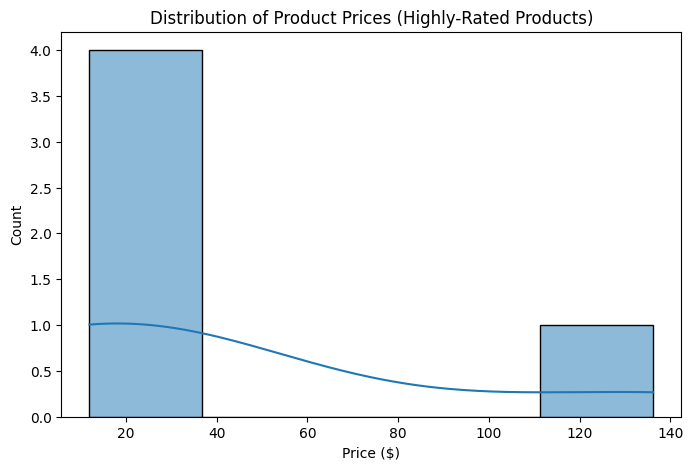

In [20]:
plt.figure(figsize=(8, 5))
sns.histplot(top_products_df['product_price'], kde=True)
plt.title('Distribution of Product Prices (Highly-Rated Products)')
plt.xlabel('Price ($)')
plt.ylabel('Count')
plt.show()

## Part 6.2 – Scatterplot of Price vs. Average Rating

Each dot is one highly-rated product, plotted at its (`price`, `average_rating`). Useful for spotting whether higher-rated products cluster at any particular price band.

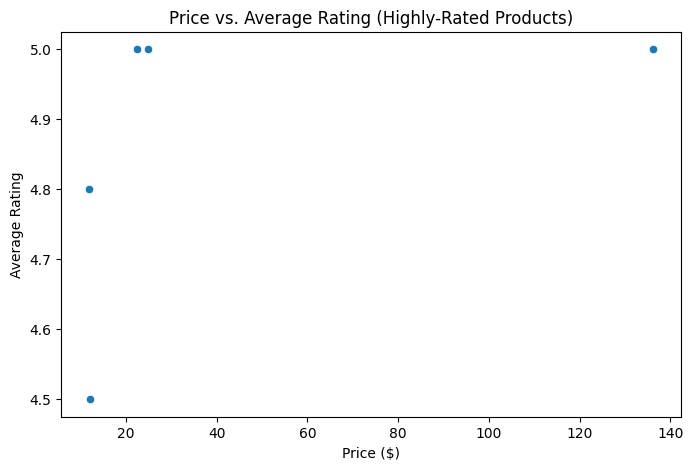

In [21]:
plt.figure(figsize=(8, 5))
sns.scatterplot(data=top_products_df, x='product_price', y='average_rating')
plt.title('Price vs. Average Rating (Highly-Rated Products)')
plt.xlabel('Price ($)')
plt.ylabel('Average Rating')
plt.show()

## Part 6.3 – Side-by-Side Dashboard with Subplots

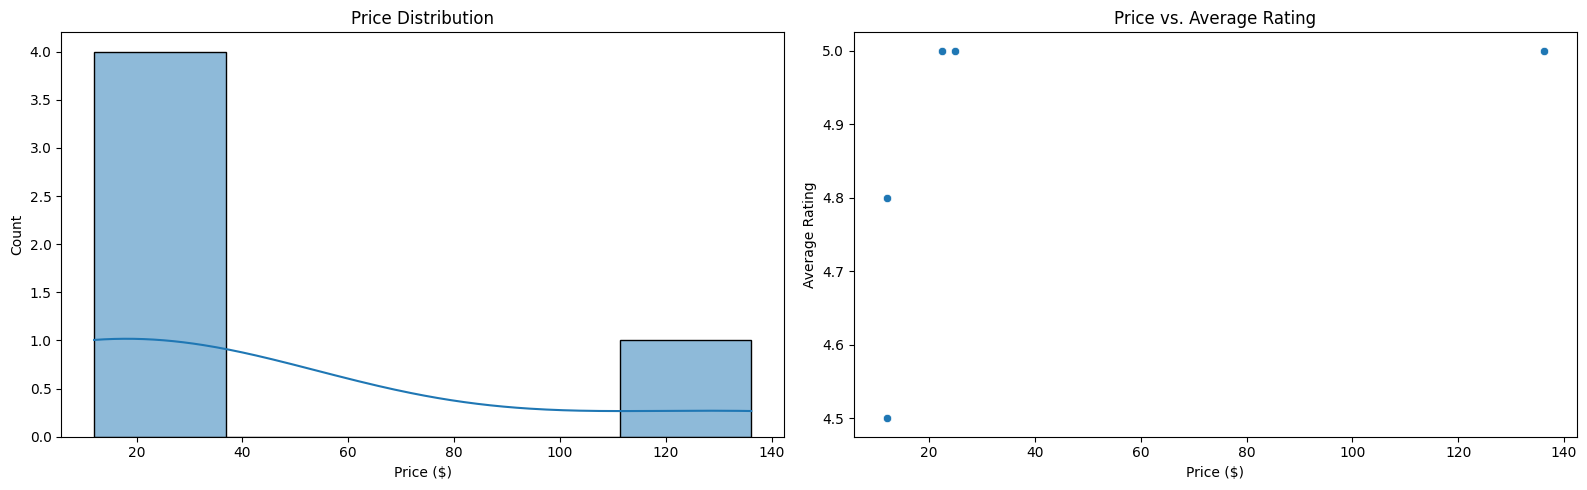

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

sns.histplot(top_products_df['product_price'], kde=True, ax=axes[0])
axes[0].set_title('Price Distribution')
axes[0].set_xlabel('Price ($)')
axes[0].set_ylabel('Count')

sns.scatterplot(data=top_products_df, x='product_price', y='average_rating', ax=axes[1])
axes[1].set_title('Price vs. Average Rating')
axes[1].set_xlabel('Price ($)')
axes[1].set_ylabel('Average Rating')

plt.tight_layout()
plt.show()

## Part 6.4 / 6.5 – Narrow Down with a Cutoff Threshold and Re-Plot

Now we tighten the filter to `average_rating >= 4.7` and `.sort_values()` so the highest-rated, then cheapest products bubble to the top.

In [23]:
highly_rated_products_df_cutoff = 4.7  # rubric: float threshold

highly_rated_products_df = top_products_df[
    top_products_df['average_rating'] >= highly_rated_products_df_cutoff
].sort_values(
    by=['average_rating', 'product_price'],
    ascending=[False, True],
).reset_index(drop=True)

print(f'Products with average_rating >= {highly_rated_products_df_cutoff}: '
      f'{len(highly_rated_products_df)}')
highly_rated_products_df

Products with average_rating >= 4.7: 4


,product_title,average_rating,product_price
0,"Enjoy VOLUMIZING ELIXIR, Style (with Sleek Ste...",5.0,22.49
1,Armáf Täg Hïm Colognė For Men 3.4 oz Eau De To...,5.0,24.84
2,Wholesale CASE of 10 - GOJO Supro Max Cherry H...,5.0,136.17
3,Suavecito X Breast Cancer Solutions - Original...,4.8,11.99


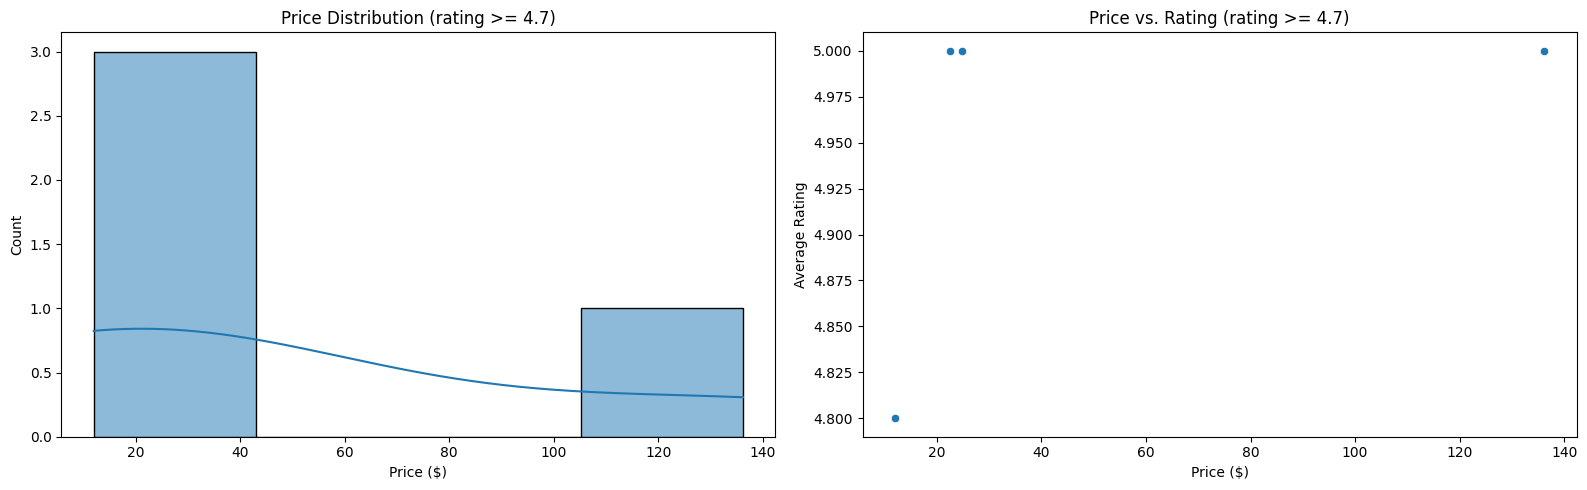

In [24]:
# Final dashboard: rating distribution + price-vs-rating scatter for the cutoff set
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

sns.histplot(highly_rated_products_df['product_price'], kde=True, ax=axes[0])
axes[0].set_title(f'Price Distribution (rating >= {highly_rated_products_df_cutoff})')
axes[0].set_xlabel('Price ($)')
axes[0].set_ylabel('Count')

sns.scatterplot(
    data=highly_rated_products_df,
    x='product_price',
    y='average_rating',
    ax=axes[1],
)
axes[1].set_title(f'Price vs. Rating (rating >= {highly_rated_products_df_cutoff})')
axes[1].set_xlabel('Price ($)')
axes[1].set_ylabel('Average Rating')

plt.tight_layout()
plt.show()

## Wrap Up – Reflection

See `user_inputs.txt` for the full reflection answers. The headline takeaways:

* **Most useful method:** `pandas.DataFrame.info()` — single call, full schema + null counts + memory in one place.
* **Biggest big-data lesson:** never load the full file. Streaming + a 100-sample cap kept us on a laptop while still letting us write code that scales.
* **Biggest cleaning lesson:** real prices arrive as `object` strings; `pd.to_numeric(..., errors='coerce')` is a one-liner safety net for that.
* **Real-world use case:** the cleaned `top_products` table is exactly the kind of curated input a recommendation or pricing-optimization model wants — high-confidence ratings, valid prices, no nulls.